In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,accuracy_score,mean_squared_error
from scipy.stats import zscore
from sklearn.ensemble import RandomForestRegressor

In [58]:
df=pd.read_csv("project1_df.csv")

In [59]:
df.head()

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,NaN,0.00,5695.612650,5695.612650,Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,Delhi


In [60]:
df.tail()

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
54995,295864,5407639888,Other,25-45,23/02/2020 10:42:04,Electronics,Yes,SEASONALOFFER21,110.89,2819.9073,2709.0173,Debit Card,Other
54996,706435,1144029904,Other,18-25,12/07/2021 15:59:21,Electronics,Yes,SEASONALOFFER21,488.59,3891.3039,3402.7139,Cash on Delivery,Bangalore
54997,649435,9587323189,Male,45-60,02/08/2024 09:30:44,Home & Kitchen,Yes,NEWYEARS,417.63,4094.6875,3677.0575,Credit Card,Mumbai
54998,982183,5032564481,Female,45-60,05/08/2020 23:57:56,Beauty and Health,Yes,SEASONALOFFER21,204.56,3977.4735,3772.9135,Credit Card,Kolkata
54999,126691,9172953722,Male,25-45,21/07/2022 09:05:18,Beauty and Health,Yes,NEWYEARS,380.81,3703.5819,3322.7719,Credit Card,Mumbai


In [61]:
df.isnull().sum()

CID                          0
TID                          0
Gender                       0
Age Group                    0
Purchase Date                0
Product Category             0
Discount Availed             0
Discount Name            27585
Discount Amount (INR)        0
Gross Amount                 0
Net Amount                   0
Purchase Method              0
Location                     0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df['Discount Name']=df['Discount Name'].fillna(0)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          55000 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


In [65]:
df.describe()

,CID,TID,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,136.986796,3012.936606,2875.949810
std,260603.330337,2.594534e+09,165.375502,1718.431066,1726.127778
min,100009.000000,1.000163e+09,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,0.000000,1562.111325,1429.551863
50%,550088.500000,5.498383e+09,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,274.115000,4342.221675,4211.407838
max,999996.000000,9.999393e+09,500.000000,8394.825600,8394.825600


In [66]:
df['Purchase Date']

0        30/08/2023 20:27:08
1        23/02/2024 09:33:46
2        06/03/2022 09:09:50
3        04/11/2020 04:41:57
4        31/05/2022 17:00:32
                ...         
54995    23/02/2020 10:42:04
54996    12/07/2021 15:59:21
54997    02/08/2024 09:30:44
54998    05/08/2020 23:57:56
54999    21/07/2022 09:05:18
Name: Purchase Date, Length: 55000, dtype: object

In [67]:
# df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])


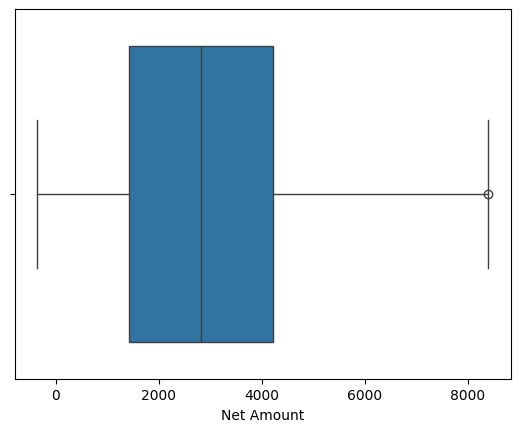

In [68]:
sns.boxplot(x=df['Net Amount'])
plt.show()

In [69]:
df['zscore']=zscore(df['Net Amount'])
df['zscore']

0       -1.283199
1        0.919901
2       -0.637918
3        1.633534
4       -0.592788
           ...   
54995   -0.096710
54996    0.305174
54997    0.464111
54998    0.519644
54999    0.258860
Name: zscore, Length: 55000, dtype: float64

In [70]:
outliers=df[df['zscore'].abs()>3]
outliers

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location,zscore
3750,773107,9470687593,Female,18-25,25/12/2023 20:47:08,Beauty and Health,No,0,0.00,8146.4208,8146.4208,Net Banking,Delhi,3.053377
4728,329974,4457950476,Male,45-60,29/12/2023 19:14:26,Other,No,0,0.00,8146.0680,8146.0680,Credit Card,Kolkata,3.053173
5521,255607,7392860072,Male,18-25,15/12/2023 15:55:16,Clothing,No,0,0.00,8361.2256,8361.2256,Credit Card,Mumbai,3.177821
9384,403680,8521672629,Male,25-45,07/12/2023 04:18:19,Electronics,No,0,0.00,8133.7704,8133.7704,Credit Card,Delhi,3.046048
11102,633881,3945430953,Female,18-25,26/12/2023 04:40:59,Beauty and Health,Yes,SAVE10,255.27,8332.4304,8077.1604,Google Pay UPI,Delhi,3.013252
13730,618556,6958210258,Female,18-25,29/12/2023 14:34:25,Beauty and Health,No,0,0.00,8143.5816,8143.5816,Credit Card,Ahmedabad,3.051732
20097,815054,4266495955,Other,18-25,26/12/2023 18:02:30,Pet Care,Yes,FESTIVE50,221.73,8322.4008,8100.6708,Credit Card,Bangalore,3.026872
20261,707601,5621236013,Female,45-60,14/12/2023 04:08:56,Toys & Games,No,0,0.00,8125.9752,8125.9752,Debit Card,Kolkata,3.041532
21848,738513,7204773289,Female,18-25,06/12/2023 04:26:33,Beauty and Health,No,0,0.00,8382.7968,8382.7968,Debit Card,Delhi,3.190318
26874,202767,5202191880,Other,18-25,11/12/2023 11:19:48,Home & Kitchen,No,0,0.00,8394.8256,8394.8256,Debit Card,Pune,3.197287


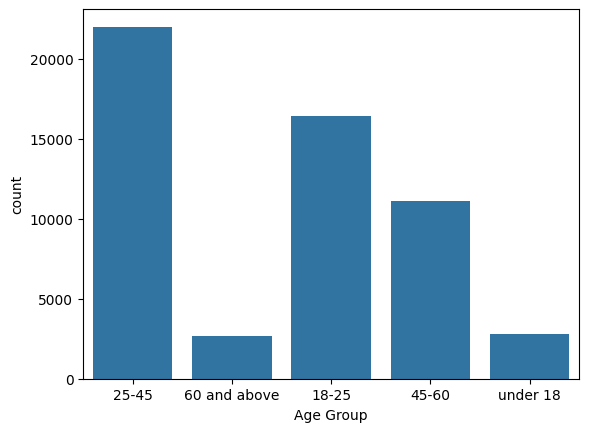

In [71]:
sns.countplot(x='Age Group', data=df)
plt.show()

<Axes: xlabel='Product Category'>

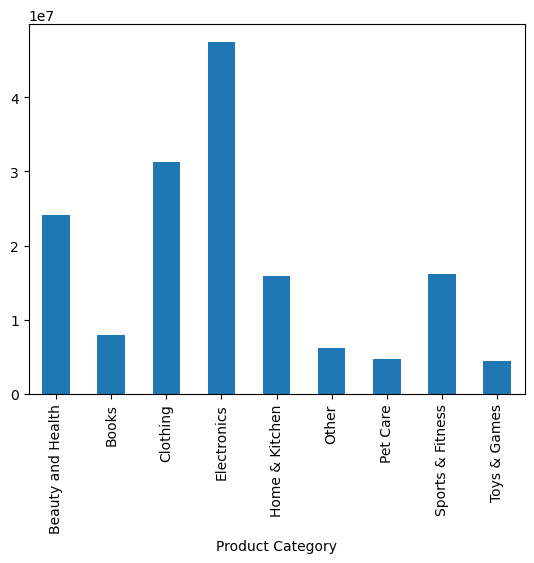

In [72]:
df.groupby('Product Category')['Net Amount'].sum().plot(kind='bar')

<Axes: xlabel='Gender', ylabel='Net Amount'>

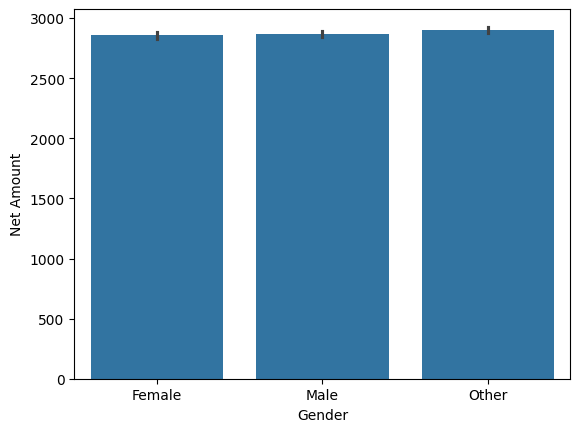

In [73]:
sns.barplot(x='Gender', y='Net Amount', data=df)

<Axes: xlabel='Location'>

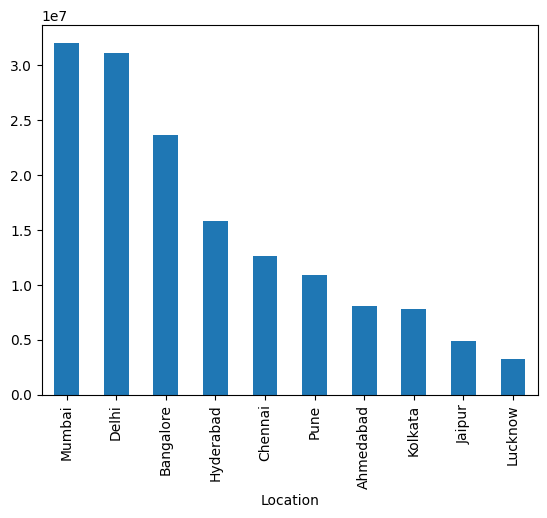

In [74]:
top_locations = df.groupby('Location')['Net Amount'].sum().sort_values(ascending=False).head(10)

top_locations.plot(kind='bar')

<Axes: xlabel='Purchase Date'>

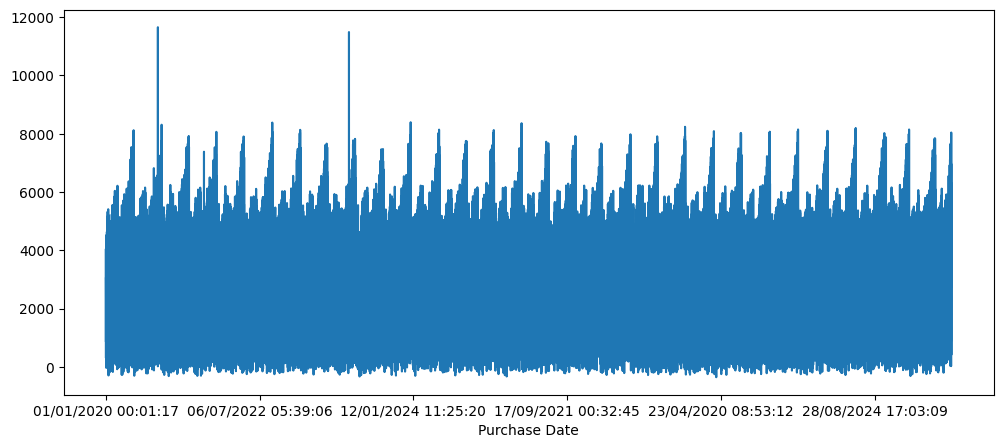

In [ ]:
# sales = df.groupby('Purchase Date')['Net Amount'].sum()

# sales.plot(figsize=(12,5))

C:\Users\Abdul\AppData\Local\Temp\ipykernel_23900\3945097748.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Month'] = pd.to_datetime(df['Purchase Date']).dt.month


<Axes: xlabel='Month', ylabel='Net Amount'>

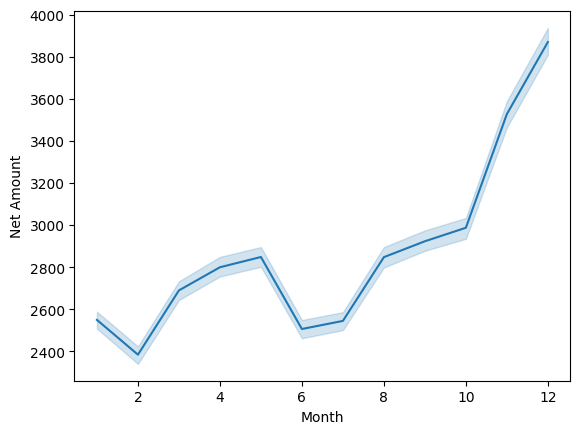

In [76]:
df['Month'] = pd.to_datetime(df['Purchase Date']).dt.month

sns.lineplot(x='Month', y='Net Amount', data=df)

In [77]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month
df['Day'] = df['Purchase Date'].dt.day

df.drop('Purchase Date', axis=1, inplace=True)
df['Net Amount'] = np.log1p(df['Net Amount'])

C:\Users\Abdul\AppData\Local\Temp\ipykernel_23900\1287559020.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
C:\Users\Abdul\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [78]:
X = df.drop(['Net Amount', 'CID', 'TID','zscore'], axis=1)
Y=df['Net Amount']

In [79]:
X = pd.get_dummies(X, drop_first=True)

In [80]:
X

,Discount Amount (INR),Gross Amount,Month,Year,Day,Gender_Male,Gender_Other,Age Group_25-45,Age Group_45-60,Age Group_60 and above,...,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kolkata,Location_Lucknow,Location_Mumbai,Location_Other,Location_Pune,Location_Srinagar,Location_Varanasi
0,64.30,725.304000,8,2023,30,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,175.19,4638.991875,2,2024,23,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,211.54,1986.372575,3,2022,6,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,False
3,0.00,5695.612650,11,2020,4,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,False
4,439.92,2292.651500,5,2022,31,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,110.89,2819.907300,2,2020,23,False,True,True,False,False,...,False,False,False,False,False,False,True,False,False,False
54996,488.59,3891.303900,7,2021,12,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54997,417.63,4094.687500,8,2024,2,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
54998,204.56,3977.473500,8,2020,5,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [81]:
Y=Y.fillna(df['Net Amount'].mean())

In [82]:
model=RandomForestRegressor(  
    n_estimators=100,
    max_depth=None,
    random_state=42
)
x_trian,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
model.fit(x_trian,y_train)
y_predict=model.predict(x_test)


In [83]:
print("MAE:", mean_absolute_error(y_test, y_predict))
print("MSE:", mean_squared_error(y_test, y_predict))
print("R2:", r2_score(y_test, y_predict))

MAE: 0.011727421921762387
MSE: 0.028275943741826237
R2: 0.9655958448741799


Index(['Discount Amount (INR)', 'Gross Amount', 'Month', 'Year', 'Day',
       'Gender_Male', 'Gender_Other', 'Age Group_25-45', 'Age Group_45-60',
       'Age Group_60 and above', 'Age Group_under 18',
       'Product Category_Books', 'Product Category_Clothing',
       'Product Category_Electronics', 'Product Category_Home & Kitchen',
       'Product Category_Other', 'Product Category_Pet Care',
       'Product Category_Sports & Fitness', 'Product Category_Toys & Games',
       'Discount Availed_Yes', 'Discount Name_FESTIVE50',
       'Discount Name_NEWYEARS', 'Discount Name_SAVE10',
       'Discount Name_SEASONALOFFER21', 'Discount Name_WELCOME5',
       'Purchase Method_Credit Card', 'Purchase Method_Debit Card',
       'Purchase Method_Google Pay UPI', 'Purchase Method_International Card',
       'Purchase Method_Net Banking', 'Purchase Method_Paytm UPI',
       'Purchase Method_PhonePe UPI', 'Location_Bangalore', 'Location_Chennai',
       'Location_Dehradun', 'Location_Delhi', '